# Segregation and heat

Bulding on [*Mobility patterns are associated with experienced income segregation in large US cities*](https://www.nature.com/articles/s41467-021-24899-8), we aim to understand how extreme heat relates to segregation in US cities.

In [1]:
from datetime import datetime, timedelta, date
import math

import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
import numpy as np
import orjson
import pandas as pd
import polars as pl
import seaborn as sns
import shapely
from tqdm import tqdm

from wpp import data, db, plot
from wpp.utils import project_root

In [2]:
# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

root = project_root()
db_path = root / "wpp.duckdb"
con = db.connect(db_path)

In [3]:
poi_query = """
    SELECT *
    FROM pois
"""
pois = con.sql(poi_query).pl()
pois.head()

<sys>:0: UserWarning: Extension type 'geoarrow.wkb' is not registered; loading as its storage type.

To avoid this warning, register the extension type or set environment variable 'POLARS_UNKNOWN_EXTENSION_TYPE_BEHAVIOR' to 'load_as_storage' or 'load_as_extension'.

In Polars 2.0, the default behavior will change to 'load_as_extension'.


ID_STORE,POI_GEOID,PERSISTENT_ID,BRAND,LOCATION_NAME,STREET_ADDRESS,CITY,REGION,ISO_COUNTRY_CODE,TOP_CATEGORY,SUB_CATEGORY,OPEN_DATE,CLOSE_DATE,LONGITUDE,LATITUDE,GEOM
str,str,str,str,str,str,str,str,str,str,str,date,date,f64,f64,binary
"""10000000""","""120330021002""","""A1_NAICS-238320""","""Painting and Wall Covering Con…","""Painting and Wall Covering Con…","""20 Keys Ct""","""Pensacola""","""FL""","""US""","""Building Finishing Contractors""","""Painting and Wall Covering Con…",1970-01-01,2038-01-01,-87.262512,30.41758,"b""\x01\x01\x00\x00\x00Ds\xf8\xff\xcc\xd0U\xc07\xf9\xd2\x80\xe6j>@"""
"""10000001""","""120050022003""","""A1_NAICS-811111""","""General Automotive Repair""","""General Automotive Repair""","""1115 W 15Th St""","""Panama City""","""FL""","""US""","""Automotive Repair and Maintena…","""General Automotive Repair """,1970-01-01,2038-01-01,-85.679278,30.174893,"b""\x01\x01\x00\x00\x00\x1b\xb9nJykU\xc0\xa1L\xa3\xc9\xc5,>@"""
"""10000003""","""011010022014""","""A1_NAICS-238320""","""Painting and Wall Covering Con…","""Painting and Wall Covering Con…","""4022 S Court St""","""Montgomery""","""AL""","""US""","""Building Finishing Contractors""","""Painting and Wall Covering Con…",1970-01-01,2038-01-01,-86.308281,32.330967,"b""\x01\x01\x00\x00\x00q\xbf\x8d\xde\xba\x93U\xc0*\xc9:\x1c]*@@"""
"""10000004""","""100010430002""","""A1_NAICS-238320""","""Painting and Wall Covering Con…","""Painting and Wall Covering Con…","""104 E Liberty St""","""Harrington""","""DE""","""US""","""Building Finishing Contractors""","""Painting and Wall Covering Con…",1970-01-01,2038-01-01,-75.574638,38.925712,"b""\x01\x01\x00\x00\x00\x11\x02M\xdf\xc6\xe4R\xc0\xa2\x00\x9b\xbd}vC@"""
"""10000006""","""340210006003""","""A1_NAICS-238320""","""Painting and Wall Covering Con…","""Painting and Wall Covering Con…","""512 Columbus Ave""","""Trenton""","""NJ""","""US""","""Building Finishing Contractors""","""Painting and Wall Covering Con…",1970-01-01,2038-01-01,-74.736076,40.21233,"b""\x01\x01\x00\x00\x00\xe0V0\xe0\x1b\xafR\xc0B;L\xa0-\x1bD@"""


In [15]:
query = """
    WITH bg AS (
        SELECT 
            GEOID, CBSAFP, CBSA_NAME, CBSA_POP_RANK, 
            MEDIAN_HH_INCOME,
            NTILE(4) OVER (PARTITION BY CBSAFP ORDER BY MEDIAN_HH_INCOME ASC) AS INCOME_GROUP
        FROM block_groups_cbsa
        WHERE LSAD = 'M1'
          AND CBSA_POP_RANK = 20
          AND MEDIAN_HH_INCOME IS NOT NULL
    )
    SELECT 
        bgv.*, 
        p.POI_GEOID, bgp.CBSAFP AS POI_CBSAFP, bgp.CBSA_NAME AS POI_CBSA_NAME,
        bgh.MEDIAN_HH_INCOME AS HOME_MEDIAN_HH_INCOME, bgh.INCOME_GROUP AS HOME_INCOME_GROUP, bgh.CBSAFP AS HOME_CBSAFP
    FROM block_group_visits bgv
    JOIN pois p ON bgv.ID_STORE = p.ID_STORE
    JOIN bg bgp ON p.POI_GEOID = bgp.GEOID
    JOIN bg bgh ON bgv.HOME_GEOID = bgh.GEOID
    WHERE bgp.CBSAFP = bgh.CBSAFP
"""
df = con.sql(query).pl()
df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

HOME_GEOID,ID_STORE,DATE_RANGE_START,DATE_RANGE_END,VISITOR_COUNTS,POI_GEOID,POI_CBSAFP,POI_CBSA_NAME,HOME_MEDIAN_HH_INCOME,HOME_INCOME_GROUP,HOME_CBSAFP
str,str,datetime[μs],datetime[μs],i32,str,str,str,f64,i64,str
"""120950110003""","""11117745""",2025-01-06 00:00:00,2025-01-12 00:00:00,39,"""120950185003""","""36740""","""Orlando-Kissimmee-Sanford, FL""",134444.0,4,"""36740"""
"""120950110003""","""11118725""",2025-01-06 00:00:00,2025-01-12 00:00:00,33,"""120950167391""","""36740""","""Orlando-Kissimmee-Sanford, FL""",134444.0,4,"""36740"""
"""120950110003""","""11129143""",2025-01-06 00:00:00,2025-01-12 00:00:00,14,"""120950148121""","""36740""","""Orlando-Kissimmee-Sanford, FL""",134444.0,4,"""36740"""
"""120950110003""","""11140138""",2025-01-06 00:00:00,2025-01-12 00:00:00,17,"""120970410042""","""36740""","""Orlando-Kissimmee-Sanford, FL""",134444.0,4,"""36740"""
"""120950110003""","""11140862""",2025-01-06 00:00:00,2025-01-12 00:00:00,32,"""121170214013""","""36740""","""Orlando-Kissimmee-Sanford, FL""",134444.0,4,"""36740"""


From the paper:
> To measure the income segregation of each place $\alpha$ in the city, we compute the proportion of total time spent at that place $\alpha$ by each income quartile $q$, $\tau _{q, \alpha}$, defining separate quartiles for each city. We define full integration of a place as $\tau _{q, \alpha} = \frac{1}{4}$ for each $q$, that is, the total time spent at venue $\alpha$ is split evenly across our four income quartiles. We then define the income segregation for each place $\alpha$, $S_\alpha$, as any deviation from our idealized measure of integration:
> $$S_{\alpha} = \frac{2}{3}\sum_{q=1}^{4}\left|\tau_{q\alpha} - \frac{1}{4}\right|$$

## Static segregation

In [16]:
poi_segregation = (
    df
    .filter(
        pl.col("HOME_INCOME_GROUP").is_not_null()
        & pl.col("VISITOR_COUNTS").is_not_null()
        & (pl.col("VISITOR_COUNTS") >= 0)
    )
    .group_by(["ID_STORE", "HOME_INCOME_GROUP"])
    .agg(
        pl.col("VISITOR_COUNTS").sum().alias("QUARTILE_VISITORS")
    )
    .with_columns(
        pl.col("QUARTILE_VISITORS")
        .sum()
        .over("ID_STORE")
        .alias("TOTAL_VISITORS")
    )
    .filter(pl.col("TOTAL_VISITORS") > 0)
    .with_columns(
        (
            pl.col("QUARTILE_VISITORS")
            / pl.col("TOTAL_VISITORS")
        ).alias("TAU")
    )
    .group_by("ID_STORE")
    .agg(
        pl.col("TOTAL_VISITORS").first(),

        (
            (2 / 3)
            * (
                (pl.col("TAU") - 0.25).abs().sum()
                + (
                    4 - pl.col("HOME_INCOME_GROUP").n_unique()
                ) * 0.25
            )
        ).alias("INCOME_SEGREGATION")
    )
)

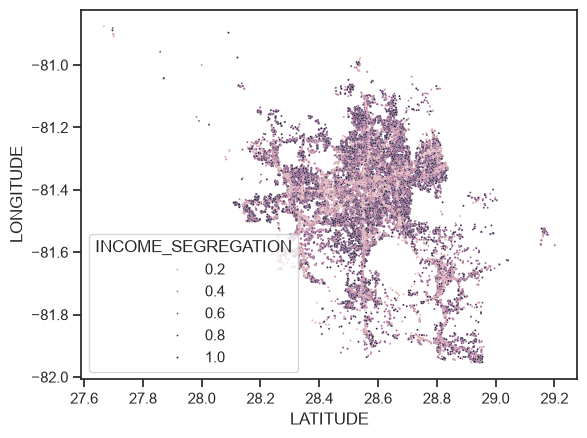

In [17]:
x = pois.join(poi_segregation, on="ID_STORE")
ax = sns.scatterplot(x, x="LATITUDE", y="LONGITUDE", hue="INCOME_SEGREGATION", s=2)

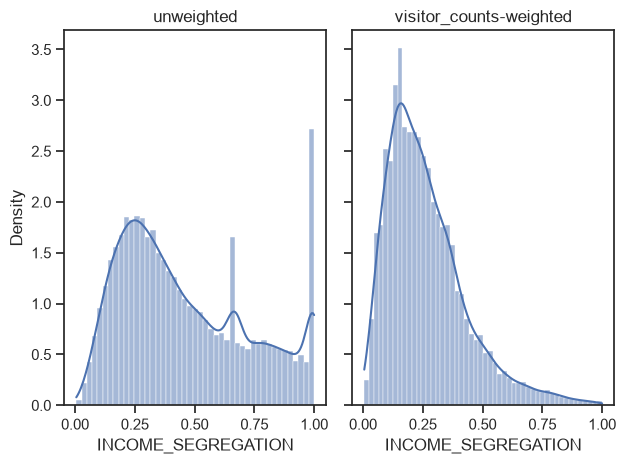

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True, sharey=True)
sns.histplot(
    x, 
    x="INCOME_SEGREGATION", 
    kde=True, 
    ax=ax1,
    stat="density"
)
sns.histplot(
    x, 
    x="INCOME_SEGREGATION", 
    weights="TOTAL_VISITORS", 
    kde=True, 
    bins=50,
    ax=ax2,
    stat="density"
)
ax1.set_title("unweighted")
ax2.set_title("visitor_counts-weighted")
fig.tight_layout()

## Time dependant segregation

In [20]:
poi_segregation_over_time = (
    df
    .filter(
        pl.col("HOME_INCOME_GROUP").is_not_null()
        & pl.col("VISITOR_COUNTS").is_not_null()
        & (pl.col("VISITOR_COUNTS") >= 0)
    )
    .group_by(["DATE_RANGE_START", "ID_STORE", "HOME_INCOME_GROUP"])
    .agg(
        pl.col("VISITOR_COUNTS").sum().alias("QUARTILE_VISITORS")
    )
    .with_columns(
        pl.col("QUARTILE_VISITORS")
        .sum()
        .over("DATE_RANGE_START", "ID_STORE")
        .alias("TOTAL_VISITORS")
    )
    .filter(pl.col("TOTAL_VISITORS") > 0)
    .with_columns(
        (
            pl.col("QUARTILE_VISITORS")
            / pl.col("TOTAL_VISITORS")
        ).alias("TAU")
    )
    .group_by("DATE_RANGE_START", "ID_STORE")
    .agg(
        pl.col("TOTAL_VISITORS").first(),

        (
            (2 / 3)
            * (
                (pl.col("TAU") - 0.25).abs().sum()
                + (
                    4 - pl.col("HOME_INCOME_GROUP").n_unique()
                ) * 0.25
            )
        ).alias("INCOME_SEGREGATION")
    )
    .sort("DATE_RANGE_START")
)

(0.0, 1.0)

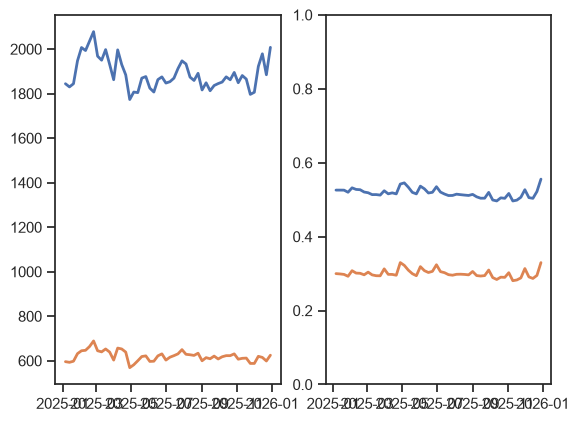

In [21]:
fig, axes = plt.subplots(1, 2, sharex=True)
poi_segregation_over_time_agg = poi_segregation_over_time.group_by("DATE_RANGE_START").agg(
    pl.col("TOTAL_VISITORS").mean(),
    pl.col("TOTAL_VISITORS").median().alias("TOTAL_VISITORS_MEDIAN"),
    pl.col("INCOME_SEGREGATION").mean(),
    (
        (pl.col("INCOME_SEGREGATION") * pl.col("TOTAL_VISITORS")).sum() / pl.col("TOTAL_VISITORS").sum()
    ).alias("INCOME_SEGREGATION_WEIGHTED")
)

axes[0].plot(poi_segregation_over_time_agg["DATE_RANGE_START"], poi_segregation_over_time_agg["TOTAL_VISITORS"], lw=2, zorder=2)
axes[0].plot(poi_segregation_over_time_agg["DATE_RANGE_START"], poi_segregation_over_time_agg["TOTAL_VISITORS_MEDIAN"], lw=2, zorder=2)
axes[1].plot(poi_segregation_over_time_agg["DATE_RANGE_START"], poi_segregation_over_time_agg["INCOME_SEGREGATION"], lw=2, zorder=2)
axes[1].plot(poi_segregation_over_time_agg["DATE_RANGE_START"], poi_segregation_over_time_agg["INCOME_SEGREGATION_WEIGHTED"], lw=2, zorder=2)

axes[1].set_ylim(0, 1)

In [22]:
seg_time = (
    poi_segregation_over_time
    .sort(["ID_STORE", "DATE_RANGE_START"])
    .with_columns(
        pl.col("INCOME_SEGREGATION")
        .shift(1)
        .over("ID_STORE")
        .alias("SEGREGATION_LAG1"),

        pl.col("DATE_RANGE_START")
        .shift(1)
        .over("ID_STORE")
        .alias("DATE_LAG1"),
    )
    .with_columns(
        (
            pl.col("INCOME_SEGREGATION")
            - pl.col("SEGREGATION_LAG1")
        ).alias("CHANGE"),

        (
            pl.col("INCOME_SEGREGATION")
            - pl.col("SEGREGATION_LAG1")
        ).abs().alias("ABS_CHANGE"),
    )
)

In [24]:
poi_stability = (
    seg_time
    .filter(pl.col("SEGREGATION_LAG1").is_not_null())
    .group_by("ID_STORE")
    .agg(
        pl.len().alias("N_TRANSITIONS"),

        pl.corr(
            "INCOME_SEGREGATION",
            "SEGREGATION_LAG1"
        ).alias("AUTOCORR_LAG1"),

        pl.col("ABS_CHANGE")
        .mean()
        .alias("MEAN_ABS_CHANGE"),

        pl.col("ABS_CHANGE")
        .median()
        .alias("MEDIAN_ABS_CHANGE"),

        pl.col("CHANGE")
        .std()
        .alias("SD_CHANGE"),

        pl.col("INCOME_SEGREGATION")
        .mean()
        .alias("MEAN_SEGREGATION"),

        pl.col("INCOME_SEGREGATION")
        .std()
        .alias("SD_SEGREGATION"),

        pl.col("TOTAL_VISITORS")
        .sum()
        .alias("TOTAL_VISITORS_ALL_PERIODS"),
    )
)

<Axes: xlabel='AUTOCORR_LAG1', ylabel='Count'>

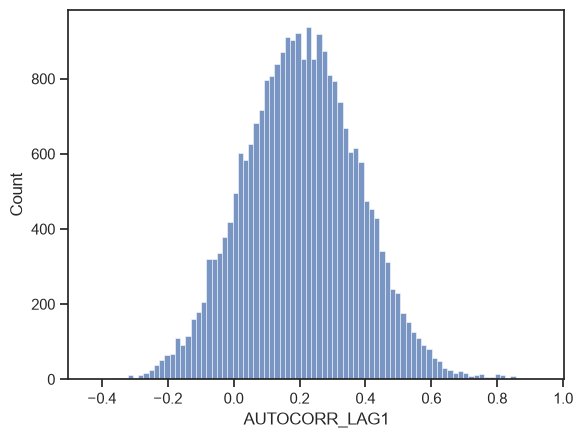

In [26]:
sns.histplot(poi_stability.filter(pl.col("N_TRANSITIONS") == 51), x="AUTOCORR_LAG1")